# Estimated distributed PV (rooftop solar) — SWIS

AEMO's `distributed-pv-new-*` files carry a single 5-minute series: **estimated** generation from
behind-the-meter rooftop solar across the SWIS. It is a model output, not a meter reading — there is
no revenue metering behind the customer's meter for AEMO to add up — so treat it as AEMO's best
estimate rather than measured truth.

It is also the series that makes the demand notebook's headline possible. Operational demand is
*net* of rooftop PV, so every megawatt here is a megawatt that never appears as grid demand.

In [1]:
# Load Estimated Distributed PV (rooftop solar) Data
import sys
sys.path.insert(0, '../src')  # Add src directory to path (go up one level from notebooks/)
from wa_data import load_dpv, to_trading_intervals

# Load with explicit path (go up one level from notebooks/)
df = load_dpv(raw='../data/raw')

YEAR = 2025   # the year every slice and chart below follows

In [2]:
from IPython.display import display

display(df.head())
df.info()
display(df.describe())

,ts,dpv_mw
0,2023-10-01 08:00:00,415.39
1,2023-10-01 08:05:00,427.91
2,2023-10-01 08:10:00,460.49
3,2023-10-01 08:15:00,486.06
4,2023-10-01 08:20:00,493.67


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307007 entries, 0 to 307006
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ts      307007 non-null  datetime64[ns]
 1   dpv_mw  307007 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.7 MB


,ts,dpv_mw
count,307007,307007.000000
mean,2025-03-17 07:55:14.004891392,486.698517
min,2023-10-01 08:00:00,0.000000
25%,2024-06-23 19:57:30,1.000000
50%,2025-03-17 07:55:00,9.070000
75%,2025-12-08 19:52:30,986.965000
max,2026-09-01 07:55:00,2321.210000
std,NaN,654.307515


In [3]:
df_agg = to_trading_intervals(df, ["dpv_mw"], ts="ts", how="mean")

In [4]:
display(df_agg.head())
df_agg.info()
display(df_agg.describe())

,ts,dpv_mw
0,2023-10-01 08:00:00,469.861667
1,2023-10-01 08:30:00,696.480000
2,2023-10-01 09:00:00,823.263333
3,2023-10-01 09:30:00,1160.718333
4,2023-10-01 10:00:00,1024.895000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51168 entries, 0 to 51167
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ts      51168 non-null  datetime64[ns]
 1   dpv_mw  51168 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 799.6 KB


,ts,dpv_mw
count,51168,51168.000000
mean,2025-03-17 07:44:59.999999744,486.701763
min,2023-10-01 08:00:00,0.020000
25%,2024-06-23 19:52:30,1.043333
50%,2025-03-17 07:45:00,11.182500
75%,2025-12-08 19:37:30,987.603333
max,2026-09-01 07:30:00,2313.165000
std,NaN,653.268814


In [5]:
# Slice the chosen year from the CONCATENATED frame — never from a single-year
# file, which is cut at 00:00 UTC (08:00 AWST) and so misses its own first
# 8 hours of January (they live in the previous year's file).
dyr = df_agg[df_agg.ts.dt.year == YEAR]

In [6]:
display(dyr.head())
dyr.info()
display(dyr.describe())

,ts,dpv_mw
21968,2025-01-01 00:00:00,0.09
21969,2025-01-01 00:30:00,0.09
21970,2025-01-01 01:00:00,0.09
21971,2025-01-01 01:30:00,0.09
21972,2025-01-01 02:00:00,0.09


<class 'pandas.core.frame.DataFrame'>
Index: 17520 entries, 21968 to 39487
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ts      17520 non-null  datetime64[ns]
 1   dpv_mw  17520 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 410.6 KB


,ts,dpv_mw
count,17520,17520.000000
mean,2025-07-02 11:45:00,489.791164
min,2025-01-01 00:00:00,0.020000
25%,2025-04-02 05:52:30,0.650000
50%,2025-07-02 11:45:00,11.394167
75%,2025-10-01 17:37:30,986.017500
max,2025-12-31 23:30:00,2083.158333
std,NaN,657.204961


## Visualisation

The same three views as the demand notebook, each solving the density problem a different way, plus
one that puts rooftop PV back next to the demand it hides:

1. **Average day by season** — collapses ~100k intervals into a mean day shape.
2. **One week at 5-minute resolution** — keeps the detail, narrows the window.
3. **Carpet plots** — every interval at once: position for time, colour for magnitude.
4. **Rooftop PV against grid demand** — why this series matters at all.

Set `YEAR` once in the next cell; everything below follows it.

In [7]:
# ── Chart setup: palette, shared theme, and derived frames ────────────────────────────────────────
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from wa_data import add_time_parts

# Categorical slots 1-3 of the reference palette, in fixed order (never cycled).
# Rooftop PV takes ORANGE throughout this notebook; demand keeps BLUE, as in the
# demand notebook. Colour follows the entity, not the chart.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

# Chart chrome, light surface
SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

# Single-hue sequential ramps: orange for PV output, blue for volatility
RAMP_BLUE   = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
RAMP_ORANGE = ["#fde3d6", "#fbc7ae", "#f8a785", "#f2865c", "#eb6834", "#c9501f", "#73290c"]


def style(fig, axes, title, subtitle=None, legend_ax=None, legend_ncol=None,
          title_y=0.98, subtitle_y=0.93):
    """Shared theme: light surface, recessive grid, muted axes, ink-coloured text.

    `axes` may be a single Axes or any array of them (e.g. from plt.subplots).
    Title/subtitle are rendered at figure level, left-aligned at the figure edge.
    Pass `legend_ax` to draw a horizontal legend just above that axes' own plot
    area (used for single-axes charts; multi-panel charts build their legend
    separately so it doesn't collide with per-panel titles).
    """
    axes_list = np.atleast_1d(axes).ravel().tolist()
    fig.patch.set_facecolor(SURFACE)
    for ax in axes_list:
        ax.set_facecolor(SURFACE)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)     # y-axis line: invisible, gridlines carry it
        ax.spines["bottom"].set_color(AXIS)
        ax.tick_params(axis="x", colors=AXIS, direction="out", length=4)
        for lbl in ax.get_xticklabels():
            lbl.set_color(MUTED)
        ax.tick_params(axis="y", colors=MUTED, length=0)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    fig.suptitle(title, x=0.01, y=title_y, ha="left", fontsize=17,
                 fontweight="bold", color=INK)
    if subtitle:
        fig.text(0.01, subtitle_y, subtitle, ha="left", va="top",
                 fontsize=11, color=INK_2)
    if legend_ax is not None:
        handles, labels = legend_ax.get_legend_handles_labels()
        if handles:
            legend_ax.legend(handles, labels, loc="lower left", bbox_to_anchor=(0, 1.02),
                              ncol=legend_ncol or len(labels), frameon=False,
                              labelcolor=INK_2)
    return fig


# The chosen year at both resolutions, with calendar / time-of-day helpers attached.
# d30 enriches the 30-min slice made above; d05 is the matching 5-min slice.
d30 = add_time_parts(dyr.copy())
d05 = add_time_parts(df[df.ts.dt.year == YEAR].copy())
print(f"{YEAR}:  30-min {len(d30):,} rows    5-min {len(d05):,} rows    {d30.date.nunique()} days")
print(f"coverage: {d05.ts.min()}  ->  {d05.ts.max()}")

# The DPV series has one known hole in the whole record (2026-07-13 13:35). Check
# rather than assume, because a gap would quietly bias every mean below.
expected = d05.date.nunique() * 288
print(f"5-min intervals: {len(d05):,} of {expected:,} expected  ->  {expected - len(d05)} missing")
print(f"peak {d05.dpv_mw.max():,.0f} MW at {d05.loc[d05.dpv_mw.idxmax(), 'ts']}   "
      f"annual energy {d05.dpv_mw.sum() / 12 / 1000:,.0f} GWh")

2025:  30-min 17,520 rows    5-min 105,120 rows    365 days
coverage: 2025-01-01 00:00:00  ->  2025-12-31 23:55:00
5-min intervals: 105,120 of 105,120 expected  ->  0 missing
peak 2,289 MW at 2025-04-09 12:05:00   annual energy 4,291 GWh


### 1. The average day, by season

Averaging every day in a season onto one 24-hour axis turns ~100,000 points into 48 per line.
The line is the mean; the shaded band spans the 10th to 90th percentile across the season's days,
so its width shows how much one day differs from the next.

Seasons are meteorological and southern-hemisphere, so Summer is Dec–Feb. Any season holding
fewer than `MIN_DAYS` days is dropped — all four survive in a complete year like 2025, but it
matters if you set `YEAR = 2026`, where the data stops on 1 September.

days per season: {'Autumn': 92, 'Spring': 91, 'Summer': 90, 'Winter': 92}
plotted: ['Summer', 'Autumn', 'Winter', 'Spring']  dropped: []


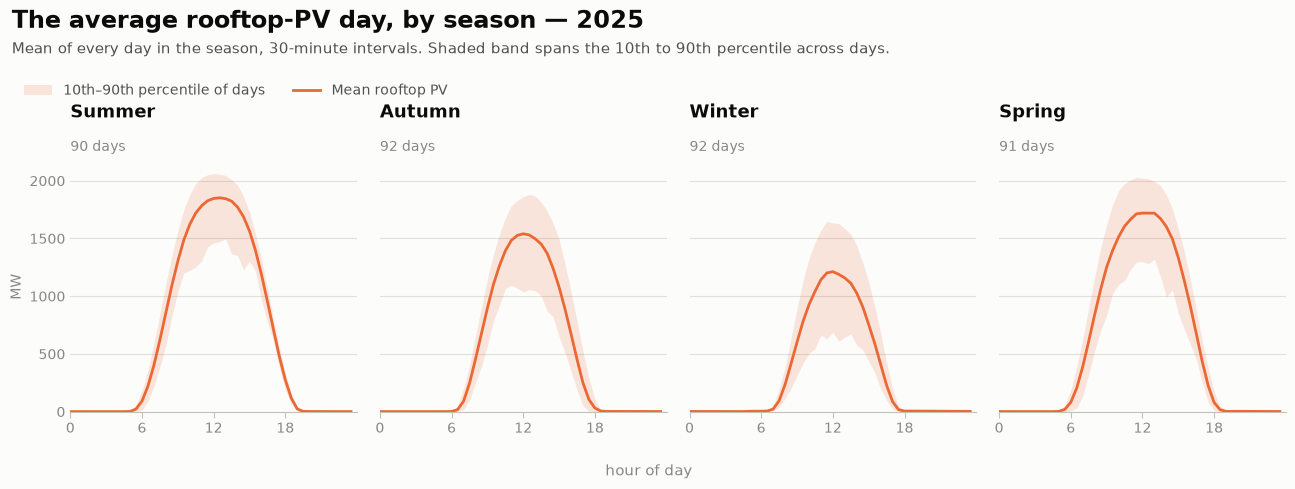

        mean daily peak (MW)  mean daily energy (GWh)
season                                               
Summer               1890.56                    15.30
Autumn               1591.49                    10.64
Winter               1302.22                     7.61
Spring               1784.83                    13.57


In [8]:
# ── Chart 1: average day shape by season ────────────────────────────────
SEASON_ORDER = ["Summer", "Autumn", "Winter", "Spring"]
MIN_DAYS = 30          # below this, an "average day" is not meaningful

days = d30.groupby("season")["date"].nunique()
seasons = [s for s in SEASON_ORDER if days.get(s, 0) >= MIN_DAYS]
print("days per season:", days.to_dict())
print("plotted:", seasons, " dropped:", [s for s in SEASON_ORDER if s not in seasons])

# Mean plus a 10th-90th percentile band, taken across the days of each season.
prof = (d30.groupby(["season", "tod_min"])["dpv_mw"]
        .agg(mean="mean",
             p10=lambda s: s.quantile(0.10),
             p90=lambda s: s.quantile(0.90))
        .reset_index())

fig, axes = plt.subplots(1, len(seasons), figsize=(13, 4.9), sharey=True)
axes = np.atleast_1d(axes)

for i, (ax, s) in enumerate(zip(axes, seasons)):
    p = prof[prof.season == s].sort_values("tod_min")
    hrs = p.tod_min / 60
    # Upper edge first, then the lower edge filled back up to it, so the fill
    # lands strictly between the two percentiles.
    ax.fill_between(hrs, p.p10, p.p90, color=ORANGE, alpha=0.16, linewidth=0,
                     label="10th–90th percentile of days" if i == 0 else None)
    ax.plot(hrs, p["mean"], color=ORANGE, linewidth=2,
            label="Mean rooftop PV" if i == 0 else None)
    ax.set_xlim(0, 24)
    ax.set_xticks([0, 6, 12, 18])
    # Panel title, stacked: season name bold/ink, day count smaller/muted.
    ax.text(0, 1.16, s, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=13, fontweight="bold", color=INK)
    ax.text(0, 1.03, f"{days[s]} days", transform=ax.transAxes, ha="left", va="bottom",
            fontsize=10, color=MUTED)

axes[0].set_ylim(bottom=0)
axes[0].set_ylabel("MW", color=MUTED)

fig.subplots_adjust(top=0.66, bottom=0.15, left=0.055, right=0.99, wspace=0.08)

# Shared legend for all panels, built once from panel 1's handles so it stays
# centred at any panel count -- placed between the subtitle and the panel titles.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.01, 0.845),
           bbox_transform=fig.transFigure, ncol=2, frameon=False,
           labelcolor=INK_2, fontsize=10)

# One centred axis label rather than one per panel, so it stays centred at any panel count
fig.text(0.5, 0.02, "hour of day", ha="center", color=MUTED, fontsize=11)

style(fig, axes, f"The average rooftop-PV day, by season — {YEAR}",
      "Mean of every day in the season, 30-minute intervals. "
      "Shaded band spans the 10th to 90th percentile across days.",
      title_y=0.97, subtitle_y=0.905)
plt.show()

# The numbers behind the shapes.
by_season = (d30.groupby(["season", "date"])["dpv_mw"]
             .agg(peak="max", energy=lambda s: s.sum() / 2 / 1000)   # 30-min MW -> GWh
             .reset_index().groupby("season")[["peak", "energy"]].mean()
             .reindex(seasons).round(2))
by_season.columns = ["mean daily peak (MW)", "mean daily energy (GWh)"]
print(by_season)

In [9]:
# ── Chart 1 in numbers: shape, spread, and whether the seasons are like-for-like ──
def hhmm(m):
    return f"{int(m) // 60:02d}:{int(m) % 60:02d}"

rows = []
for s in seasons:
    p = prof[prof.season == s].set_index("tod_min")
    lit = p.index[p["mean"] > 20]          # "generating" = seasonal mean above 20 MW
    pk = p["mean"].idxmax()
    rows.append({"season": s,
                 "first > 20 MW": hhmm(lit.min()), "last > 20 MW": hhmm(lit.max()),
                 "window (h)": (lit.max() - lit.min()) / 60 + 0.5,
                 "peak time": hhmm(pk), "mean at peak": p.loc[pk, "mean"],
                 "p10 at peak": p.loc[pk, "p10"], "p90 at peak": p.loc[pk, "p90"],
                 "band / mean (%)": (p.loc[pk, "p90"] - p.loc[pk, "p10"]) / p.loc[pk, "mean"] * 100})
print("Average-day features (MW unless stated):")
print(pd.DataFrame(rows).set_index("season").round(1).to_string())

# Day-to-day spread in energy, the quantity the band is a picture of
day_gwh = d05.groupby(["season", "date"]).dpv_mw.sum().div(12 * 1000).rename("gwh").reset_index()
spread = day_gwh.groupby("season").gwh.agg(
    mean="mean", min="min", p10=lambda s: s.quantile(0.10),
    p90=lambda s: s.quantile(0.90), max="max", cv=lambda s: s.std() / s.mean())
print(f"\nDaily energy by season, {YEAR} (GWh; cv = std / mean):")
print(spread.reindex(seasons).round(2).to_string())
print(f"Summer / Winter:  mean daily energy {spread.loc['Summer', 'mean'] / spread.loc['Winter', 'mean']:.2f}x   "
      f"mean at peak {rows[0]['mean at peak'] / rows[2]['mean at peak']:.2f}x")

# Like-for-like check: installed capacity keeps growing, so is a later season inflated?
# The 90th percentile of daily peaks per month is a rough clear-day ceiling.
alld = add_time_parts(df).groupby("date").agg(
    year=("year", "first"), month=("month", "first"),
    peak=("dpv_mw", "max"), gwh=("dpv_mw", lambda s: s.sum() / 12 / 1000))
print("\nMean daily energy by month, whole record (GWh). Oct 2023 and Sep 2026 are partial:")
print(alld.pivot_table(index="year", columns="month", values="gwh", aggfunc="mean").round(1).to_string())
print("\nClear-day ceiling by month: 90th percentile of daily peak (MW):")
print(alld.pivot_table(index="year", columns="month", values="peak",
                       aggfunc=lambda s: s.quantile(0.9)).round(0).to_string())

Average-day features (MW unless stated):
       first > 20 MW last > 20 MW  window (h) peak time  mean at peak  p10 at peak  p90 at peak  band / mean (%)
season                                                                                                          
Summer         05:30        19:00        14.0     12:30        1851.9       1470.9       2057.3             31.7
Autumn         07:00        18:00        11.5     12:00        1540.3       1035.9       1862.0             53.6
Winter         07:00        17:00        10.5     12:00        1212.4        688.4       1633.5             77.9
Spring         06:00        18:00        12.5     12:00        1719.6       1300.6       2022.8             42.0

Daily energy by season, 2025 (GWh; cv = std / mean):
         mean   min    p10    p90    max    cv
season                                        
Summer  15.30  7.41  12.08  17.42  17.92  0.15
Autumn  10.64  4.02   7.08  13.76  14.84  0.23
Winter   7.61  3.30   4.69  10.56  13.1

### Findings

Numbers are from the two cells above (2025, 30-minute intervals unless stated).

- Every season has the same single midday arc, peaking at 12:00–12:30. The mean at the peak falls from 1,852 MW in Summer to 1,212 MW in Winter.
- The generating window (seasonal mean above 20 MW) runs 14.0 hours in Summer (05:30–19:00) against 10.5 hours in Winter (07:00–17:00).
- Summer delivers 2.0× Winter's daily energy (15.3 vs 7.6 GWh) but only 1.5× its peak. The energy gap is wider than the peak gap because summer days are both longer and more consistent.
- Day-to-day variability rises steadily towards Winter. At the peak, the 10th–90th percentile band is 32% of the mean in Summer and 78% in Winter, and the coefficient of variation of daily energy doubles (0.15 → 0.31). A tenth of winter days produce 4.7 GWh or less; the worst produced 3.3 GWh, against 17.9 GWh on the best summer day.
- Spring out-produces Autumn by 28% (13.6 vs 10.6 GWh per day) with a narrower band (42% vs 54%), although their generating windows differ by only an hour. This is consistent with the sun sitting higher in meteorological Spring (Sep–Nov, leading into the December solstice) than in Autumn (Mar–May, leading into the June solstice). Some of the gap may also be capacity added during the year (see caveat).

> **Caveat — capacity growth, and a year-on-year inconsistency.** The clear-day ceiling (90th percentile of daily peaks) rises year on year from January to August, e.g. January 1,799 → 1,994 → 2,095 MW across 2024–2026, consistent with more rooftop systems. Within 2025 the rise is small (1,994 MW in January vs 2,082 MW in December, +4%), so unlike storage charging in the demand notebook, the seasons of 2025 are roughly comparable. However, **September–November 2024 has a higher ceiling (2,103–2,266 MW) than September–November 2025 (1,972–2,065 MW)**, and more energy in October and November, despite a year of additional capacity. A cloudier spring 2025 would pull the 90th percentile down somewhat, but weather is an unlikely full explanation for a lower clear-day ceiling. Curtailment or a revision to AEMO's estimate are possible causes; this data cannot distinguish them. Be careful with year-on-year comparisons of this series.

### Implication
- [placeholder]

### 2. One week, at full 5-minute resolution

Averaging hides how sharply rooftop PV moves. This keeps every 5-minute reading and narrows the
window to a week instead.

`ANCHOR` is 9 April 2025, the day with the largest total 5-minute movement of 2025 and the year's
highest single reading (2,289 MW). Change it to look at any other week: `2025-12-21` is the
highest-energy day of the year, `2025-08-02` the lowest.

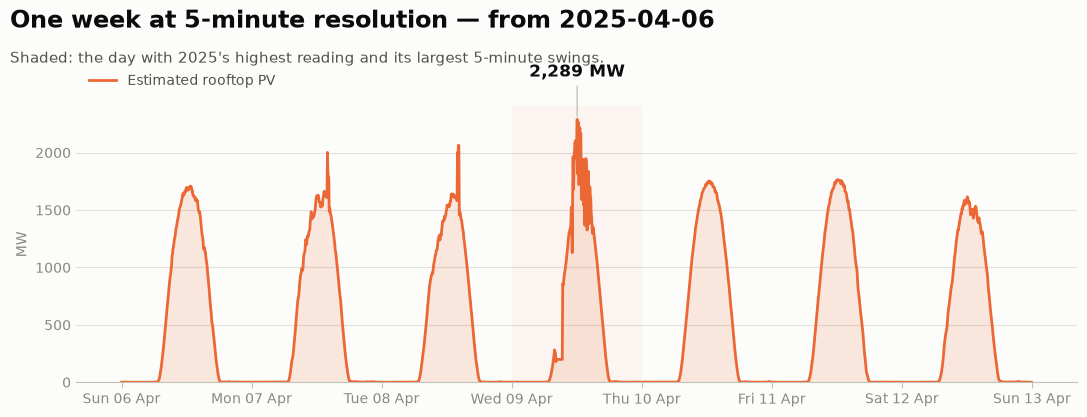

            peak (MW)  energy (GWh)  total 5-min movement (MW)
date                                                          
2025-04-06     1708.5          11.8                     3662.0
2025-04-07     2001.8          11.5                     4784.6
2025-04-08     2063.3          11.2                     4707.0
2025-04-09     2289.3          11.3                    13042.1
2025-04-10     1752.6          12.1                     3609.5
2025-04-11     1765.9          11.9                     3679.8
2025-04-12     1615.3          10.8                     3876.8


In [10]:
# ── Chart 2: one week in 5-minute detail ─────────────────────────────────
ANCHOR = pd.Timestamp("2025-04-09")     # most volatile day of 2025; also its highest 5-min reading
start  = ANCHOR - pd.Timedelta(days=3)
wk = d05[(d05.ts >= start) & (d05.ts < start + pd.Timedelta(days=7))]

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.fill_between(wk.ts, 0, wk.dpv_mw, color=ORANGE, alpha=0.14, linewidth=0)
ax.plot(wk.ts, wk.dpv_mw, color=ORANGE, linewidth=2, label="Estimated rooftop PV")

# Mark the anchor day so the contrast with its neighbours is findable, not hunted for.
ax.axvspan(ANCHOR, ANCHOR + pd.Timedelta(days=1), color=ORANGE, alpha=0.05, linewidth=0)
pk = wk.loc[wk.dpv_mw.idxmax()]
ax.annotate(f"{pk.dpv_mw:,.0f} MW", xy=(pk.ts, pk.dpv_mw), xytext=(0, 28),
            textcoords="offset points", ha="center", va="bottom",
            color=INK, fontsize=12, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=1))

ax.set_ylim(bottom=0)
ax.set_ylabel("MW", color=MUTED)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))

fig.subplots_adjust(top=0.74, bottom=0.14, left=0.07, right=0.98)
style(fig, ax, f"One week at 5-minute resolution — from {start.date()}",
      "Shaded: the day with 2025's highest reading and its largest 5-minute swings.",
      legend_ax=ax, legend_ncol=1, title_y=0.95, subtitle_y=0.86)
plt.show()

# Quantify the difference the eye is picking up: total absolute 5-minute movement per day.
wk_var = (wk.assign(ramp=wk.dpv_mw.diff().abs())
          .groupby("date").agg(**{"peak (MW)": ("dpv_mw", "max"),
                                  "energy (GWh)": ("dpv_mw", lambda s: s.sum() / 12 / 1000),
                                  "total 5-min movement (MW)": ("ramp", "sum")}).round(1))
print(wk_var)

In [11]:
# ── Chart 2 in numbers: is the anchor day's volatility real? ─────────────────
from wa_data import load_demand

def frozen_runs(frame, min_len=4):
    """Runs of identical consecutive 5-minute readings within a day."""
    f = frame.sort_values("ts")
    key = (f.dpv_mw.ne(f.dpv_mw.shift()) | f.date.ne(f.date.shift())).cumsum()
    r = f.groupby(key).agg(start=("ts", "first"), end=("ts", "last"),
                           intervals=("ts", "size"), mw=("dpv_mw", "first"))
    return r[r.intervals >= min_len].sort_values("intervals", ascending=False).reset_index(drop=True)

day = d05[d05.date == ANCHOR]
print(f"Daytime (08–16) frozen runs on {ANCHOR.date()}:")
print(frozen_runs(day[day.hour.between(8, 15)]).to_string(index=False))
print(f"\n{ANCHOR.date()} 07:55–09:35:")
print(day[day.tod_min.between(7 * 60 + 55, 9 * 60 + 35)][["ts", "dpv_mw"]].to_string(index=False))

# Cross-check against metered grid demand, which does not depend on the DPV model.
# Real PV swings should appear, inverted, in grid demand at the same 5-minute step.
dem = load_demand(raw='../data/raw')
wkx = wk.merge(dem, on="ts").sort_values("ts")
wkx = wkx.assign(d_dpv=wkx.dpv_mw.diff(), d_uod=wkx.unscheduled_demand_mw.diff())
mid = wkx[wkx.tod_min.between(9 * 60, 16 * 60)]
check = mid.groupby("date").apply(lambda g: pd.Series({
    "DPV movement (MW)": g.d_dpv.abs().sum(),
    "grid-demand movement (MW)": g.d_uod.abs().sum(),
    "corr of 5-min changes": g.d_dpv.corr(g.d_uod)}), include_groups=False)
print("\n09:00–16:00 each day of the week, total absolute 5-minute change:")
print(check.round(2).to_string())

# One-interval out-and-back spikes (> 300 MW each way) across the year
st = d05.sort_values("ts").assign(step=lambda x: x.dpv_mw.diff())
st = st.assign(next_step=st.step.shift(-1))
spikes = st[(st.step.abs() > 300) & (st.next_step.abs() > 300)
            & (np.sign(st.step) != np.sign(st.next_step))]
print(f"\nOne-interval spikes in {YEAR} (> 300 MW out and straight back): {len(spikes)}")
print(spikes[["ts", "dpv_mw", "step", "next_step"]].round(0).to_string(index=False))

# How the anchor day ranks, and the clear days it is compared against
movement = st.groupby("date").step.apply(lambda s: s.abs().sum())
daily = d05.groupby("date").agg(peak_mw=("dpv_mw", "max"), gwh=("dpv_mw", lambda s: s.sum() / 12 / 1000))
daily["movement_mw"] = movement
print(f"\nTotal 5-minute movement: {ANCHOR.date()} {movement[ANCHOR]:,.0f} MW, "
      f"next highest day {movement.nlargest(2).iloc[1]:,.0f} MW, median day {movement.median():,.0f} MW")
print(f"\nHighest 8 daily peaks, {YEAR}:")
print(daily.nlargest(8, "peak_mw").round(1).to_string())

# Is the anchor day unusual in having frozen readings? Whole record, daytime only.
full = add_time_parts(df)
runs_all = frozen_runs(full[full.hour.between(8, 15)])
print(f"\nDaytime (08–16) frozen runs of >= 4 intervals, whole record: {len(runs_all)}")
print(runs_all.to_string(index=False))

print("\nAnnual maximum 5-minute reading:")
print(full.loc[full.groupby("year").dpv_mw.idxmax(), ["ts", "dpv_mw"]].to_string(index=False))

Daytime (08–16) frozen runs on 2025-04-09:
              start                 end  intervals     mw
2025-04-09 08:15:00 2025-04-09 09:20:00         14 199.06

2025-04-09 07:55–09:35:
                 ts  dpv_mw
2025-04-09 07:55:00  281.31
2025-04-09 08:00:00  250.65
2025-04-09 08:05:00  250.65
2025-04-09 08:10:00  178.54
2025-04-09 08:15:00  199.06
2025-04-09 08:20:00  199.06
2025-04-09 08:25:00  199.06
2025-04-09 08:30:00  199.06
2025-04-09 08:35:00  199.06
2025-04-09 08:40:00  199.06
2025-04-09 08:45:00  199.06
2025-04-09 08:50:00  199.06
2025-04-09 08:55:00  199.06
2025-04-09 09:00:00  199.06
2025-04-09 09:05:00  199.06
2025-04-09 09:10:00  199.06
2025-04-09 09:15:00  199.06
2025-04-09 09:20:00  199.06
2025-04-09 09:25:00  856.98
2025-04-09 09:30:00  846.10
2025-04-09 09:35:00  880.87



09:00–16:00 each day of the week, total absolute 5-minute change:
            DPV movement (MW)  grid-demand movement (MW)  corr of 5-min changes
date                                                                           
2025-04-06            1842.20                    1715.61                  -0.53
2025-04-07            2946.73                    2031.45                  -0.21
2025-04-08            2937.37                    1380.05                  -0.12
2025-04-09           11687.71                    1557.21                  -0.17
2025-04-10            1788.13                    1606.21                  -0.78
2025-04-11            1979.25                    1646.81                  -0.71
2025-04-12            2292.42                    1805.35                  -0.54

One-interval spikes in 2025 (> 300 MW out and straight back): 4
                 ts  dpv_mw   step  next_step
2025-04-09 11:10:00  1129.0 -307.0      520.0
2025-04-09 12:25:00  1721.0 -543.0      425.0
2025-04-09

### Findings

Numbers are from the two cells above.

- 9 April 2025 stands out on every volatility measure. Its total 5-minute movement (13,042 MW) is 1.8× the next-highest day of 2025 and 3.2× the median day. It also holds the year's highest reading, 2,289 MW, about 200 MW above any other day; the next seven highest days, all clear days in November–December, cluster tightly at 2,081–2,092 MW. Yet its energy (11.3 GWh) is ordinary for the week.
- **The anchor day's volatility is most likely a data artefact, not broken cloud.** Three independent signs:
  - **A frozen reading.** The estimate sits at exactly 199.06 MW for 14 consecutive intervals (08:15–09:20, 70 minutes) during the morning ramp, when output should be rising. It then jumps +658 MW in a single step at 09:25, the largest 5-minute rise of 2025.
  - **Out-and-back spikes.** Three of 2025's four one-interval spikes (more than 300 MW out and straight back) fall on this day, at 11:10, 12:25 and 13:10.
  - **Grid demand does not corroborate it.** Real swings in rooftop PV must show up, inverted, in metered grid demand, which does not depend on AEMO's PV model. Between 09:00 and 16:00, estimated PV moved 11,688 MW in total on 9 April but grid demand moved only 1,557 MW, no more than on neighbouring days. On the smooth days that follow (10–12 Apr) the two move by similar amounts (1,788–2,292 vs 1,606–1,805 MW) and track each other closely (correlation −0.54 to −0.78); on 9 April the correlation is −0.17.
- **The 2,289 MW annual peak is therefore not a trustworthy record.** 7 and 8 April are also weakly coupled to grid demand (correlation −0.21 and −0.12, with PV moving 1.5–2.1× as much), and the chart shows isolated spikes on both, so the problem may not be confined to one day.
- Frozen readings recur across the record: 11 daytime runs of 20 minutes or more, 8 of them in 2024. They include two hours stuck at 48 MW on the morning of 28 May 2024 and 55 minutes at 2,004 MW on 20 September 2025. On 18 January 2024 the estimate reads exactly 0 MW for two spells around 13:30 on a summer afternoon, which cannot be real output. The 2023 annual maximum is a suspiciously round 2,200.00 MW.
- The one other 2025 spike, 19 November at 09:45 (+624 MW then −714 MW), coincides with the single-interval dip in grid demand already flagged in the demand notebook, so that event appears in both series.

> **Caveat — detection is conservative.** These checks only catch exact repeats and large out-and-back spikes. A model error that is smooth, or moves with the weather, would pass all of them. Grid demand also moves for its own reasons, so the cross-check is only decisive when the mismatch is large, as it is here. Flag or exclude these intervals in any modelling, and prefer daily energy over single-interval maxima when quoting records.

### Implication
- [placeholder]

### 3. Carpet plots — every interval of the year at once

No aggregation, no window: one column per day, one row per time of day, magnitude as colour.
Seasonal drift reads left-to-right; the daily cycle reads top-to-bottom.

The second carpet keeps the layout but swaps the measure for **volatility**: the mean absolute
change between consecutive 5-minute readings within each half hour.

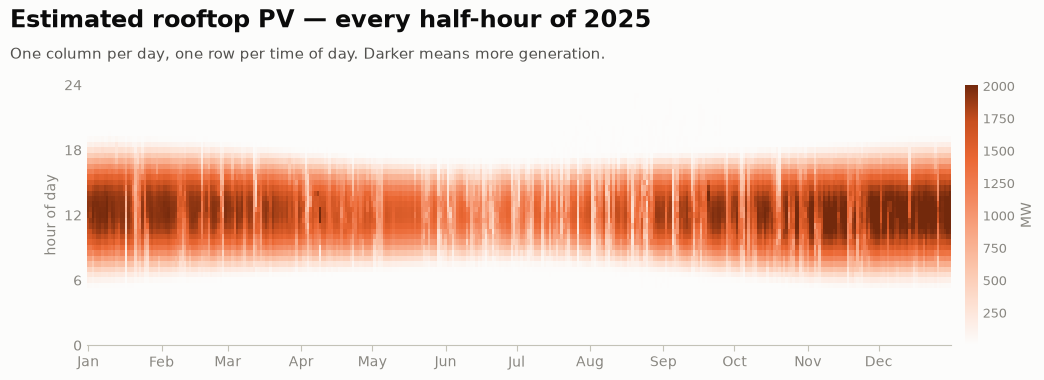

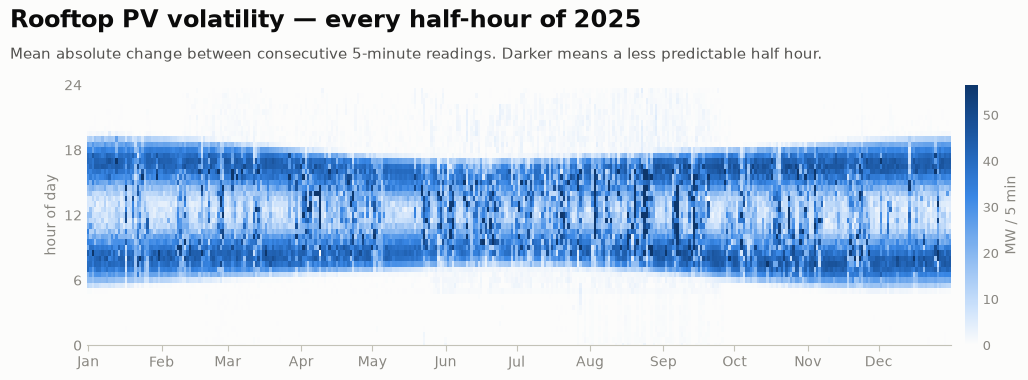

In [12]:
# ── Chart 3: carpet plots ──────────────────────────────────────
def to_surface(ramp):
    """Anchor a single-hue ramp's zero end on the chart surface.

    Half of a solar carpet is night. Left alone, the ramp's lightest step paints
    every zero a visible tint and the plot spends ink on nothing -- the demand
    carpets never hit this because demand has no zeros. Blending the low end into
    the surface lets night recede so the lit envelope draws itself.
    """
    return LinearSegmentedColormap.from_list("surface_ramp", [SURFACE] + list(ramp))


def carpet(frame, col, title, subtitle, ramp, transform=None, unit="MW", figsize=(11, 4.2)):
    v = frame[col] if transform is None else transform(frame[col])
    piv = (frame.assign(_v=v)
           .pivot_table(index="tod_min", columns="date", values="_v", aggfunc="mean")
           .sort_index())
    # Clip the colour range to the 1st-99th percentile: a handful of extreme
    # intervals otherwise compress the ramp and wash out the daily structure.
    lo, hi = np.nanpercentile(piv.values.astype(float), [1, 99])
    dates = pd.to_datetime(piv.columns)
    hours = piv.index / 60

    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(dates, hours, piv.values, cmap=to_surface(ramp),
                          vmin=lo, vmax=hi, shading="auto")
    cbar = fig.colorbar(mesh, ax=ax, pad=0.015, fraction=0.05)
    cbar.set_label(unit, color=MUTED, fontsize=10)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors=MUTED, length=0, labelsize=9)

    ax.set_ylim(0, 24)
    ax.set_yticks([0, 6, 12, 18, 24])
    ax.set_ylabel("hour of day", color=MUTED)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    fig.subplots_adjust(top=0.76, bottom=0.14, left=0.08, right=0.92)
    style(fig, ax, title, subtitle, title_y=0.94, subtitle_y=0.85)
    ax.grid(False)   # heatmap covers the full plot area; gridlines would just draw over it
    return fig, ax


carpet(d30, "dpv_mw",
       f"Estimated rooftop PV — every half-hour of {YEAR}",
       "One column per day, one row per time of day. Darker means more generation.",
       RAMP_ORANGE)
plt.show()

# Volatility: mean absolute 5-minute change, averaged into each half hour.
vol = (d05.assign(ramp=d05.dpv_mw.diff().abs())
       .set_index("ts")["ramp"].resample("30min", label="left", closed="left").mean()
       .reset_index())
vol = add_time_parts(vol)

carpet(vol, "ramp",
       f"Rooftop PV volatility — every half-hour of {YEAR}",
       "Mean absolute change between consecutive 5-minute readings. "
       "Darker means a less predictable half hour.",
       RAMP_BLUE, unit="MW / 5 min")
plt.show()

In [13]:
# ── Chart 3 in numbers: day length, cloudy days, and where volatility sits ───
# Generation window on the average day of each month (mean above 20 MW)
mprof = d30.groupby(["month", "tod_min"]).dpv_mw.mean().reset_index()
win = mprof[mprof.dpv_mw > 20].groupby("month").tod_min.agg(["min", "max"])
print(f"Generation window by month, {YEAR} (average day, mean > 20 MW):")
print(pd.DataFrame({"first": win["min"].map(hhmm), "last": win["max"].map(hhmm),
                    "hours": (win["max"] - win["min"]) / 60 + 0.5}).to_string())

# Pale columns: days producing under 60% of the best day within +/- 7 days
dg = daily[["gwh"]].assign(season=d05.groupby("date").season.first())
dg["local_best"] = dg.gwh.rolling(15, center=True, min_periods=1).max()
dg["dull"] = dg.gwh < 0.6 * dg.local_best
print("\nDays under 60% of the local 15-day best, by season:",
      dg.groupby("season").dull.sum().reindex(seasons).to_dict())

# Volatility by season and time of day
BLOCKS = ["00–05", "05–09", "09–11", "11–14", "14–16", "16–19", "19–24"]
st["block"] = pd.cut(st.hour, [-1, 4, 8, 10, 13, 15, 18, 23], labels=BLOCKS)
st["abs_step"] = st.step.abs()
print(f"\nMean absolute 5-minute change by season and time of day, {YEAR} (MW):")
print(st.pivot_table(index="season", columns="block", values="abs_step",
                     aggfunc="mean", observed=True).reindex(seasons).round(1).to_string())

smooth = movement[movement <= movement.quantile(0.2)].index
print("\nSame, on the 20% smoothest days only (MW):")
print(st[st.date.isin(smooth)].groupby("block", observed=True).abs_step.mean().round(1).to_string())

mid = st[st.hour.between(11, 13)]
print("\nMidday (11:00–14:00) movement relative to output: mean |change| / mean MW (%):")
print(mid.groupby("season").apply(lambda g: g.abs_step.mean() / g.dpv_mw.mean() * 100,
                                  include_groups=False).reindex(seasons).round(2).to_string())

# Night-time readings, when PV output should be zero
night = d05[(d05.hour >= 21) | (d05.hour < 4)]
print(f"\nNight (21:00–04:00) readings, {YEAR}: mean {night.dpv_mw.mean():.2f} MW, "
      f"max {night.dpv_mw.max():.1f} MW, share above 5 MW {(night.dpv_mw > 5).mean():.1%}")
print(night.groupby("month").dpv_mw.agg(["mean", "max"]).round(2).T.to_string())
night_gwh = night.dpv_mw.sum() / 12 / 1000
print(f"Night readings sum to {night_gwh:.1f} GWh, "
      f"{night_gwh / (d05.dpv_mw.sum() / 12 / 1000):.2%} of {YEAR} rooftop PV energy")

Generation window by month, 2025 (average day, mean > 20 MW):
       first   last  hours
month                     
1      06:00  19:00   13.5
2      06:30  18:30   12.5
3      06:30  18:00   12.0
4      07:00  17:30   11.0
5      07:00  17:00   10.5
6      07:30  17:00   10.0
7      07:30  17:00   10.0
8      07:00  17:30   11.0
9      06:30  17:30   11.5
10     06:00  18:00   12.5
11     05:30  18:30   13.5
12     05:30  19:00   14.0

Days under 60% of the local 15-day best, by season: {'Summer': 3, 'Autumn': 7, 'Winter': 25, 'Spring': 8}

Mean absolute 5-minute change by season and time of day, 2025 (MW):
block   00–05  05–09  09–11  11–14  14–16  16–19  19–24
season                                                 
Summer    0.0   24.9   26.5   12.8   24.0   35.2    1.2
Autumn    0.1   16.3   30.5   20.5   31.2   22.6    0.4
Winter    0.2   11.0   31.8   25.0   31.7   14.9    0.9
Spring    0.1   24.4   29.2   19.2   29.4   29.6    0.4

Same, on the 20% smoothest days only (MW):
bloc

### Findings

Numbers are from the cell above (2025).

#### Estimated rooftop PV
- The lit envelope follows day length. On the average day of each month, generation starts at 05:30 and ends at 19:00 in December (14.0 hours), narrowing to 07:30–17:00 in June and July (10.0 hours). The shift is symmetric: two hours at each end.
- Pale columns (dull days) cluster in Winter. 25 winter days produced under 60% of the best day within a week either side, against 7 in Autumn, 8 in Spring and only 3 in Summer.

#### Volatility
- The darkest bands sit mid-morning (09:00–11:00) and mid-afternoon (14:00–16:00), not at sunrise and sunset. They are where the daily arc is steepest, and they are geometry more than weather: on the 20% smoothest days they are still the most volatile blocks (28.5 and 27.9 MW per 5 minutes), against 10.9 MW at 05:00–09:00 and 13.9 MW at 16:00–19:00. This part of the movement is largely predictable.
- The weather signal is in the middle of the day. Midday (11:00–14:00) movement is 12.8 MW per 5 minutes in Summer against 25.0 MW in Winter; relative to output, the gap is 3× (0.70% vs 2.13%). Summer middays are the calmest daylight hours of the year; winter middays are where cloud makes output unpredictable. This mirrors the dull-day count above.
- Summer's most volatile block is 16:00–19:00 (35.2 MW per 5 minutes, the highest of any season and block). Long summer days push the steep afternoon descent into the early evening, where it overlaps the start of the evening demand ramp.
- The estimate is not zero at night. Between 21:00 and 04:00 it averages 1.07 MW and reaches 13.0 MW, with 4% of night intervals above 5 MW, highest in July–September (monthly means 2.0–2.8 MW). Rooftop PV cannot generate in the dark, so this is a property of the estimate. It is negligible for energy totals (2.7 GWh, 0.06% of the year) but matters for any "PV > 0 means daylight" filter.

### Implication
- [placeholder]

### 4. What rooftop PV does to grid demand

Operational demand is measured at the grid, so it is already *net* of rooftop PV. Adding the two back
together approximates the underlying consumer load:

```
underlying demand ≈ unscheduled operational demand + estimated rooftop PV
```

**Stated assumption, and it is approximate.** Operational demand includes transmission and
distribution losses; rooftop PV serves load behind the meter without incurring them, so the sum
slightly overstates true underlying demand. Unscheduled operational demand is used rather than
operational demand so that grid-scale battery charging stays out of the picture (see the demand
notebook's identity check).

The window plotted is the three days around 2025's lowest 5-minute grid demand.

minimum unscheduled demand 2025: 379 MW at 2025-11-15 12:45:00
  rooftop PV at that moment: 2,026 MW
  share of underlying demand met by rooftop PV: 84.2%


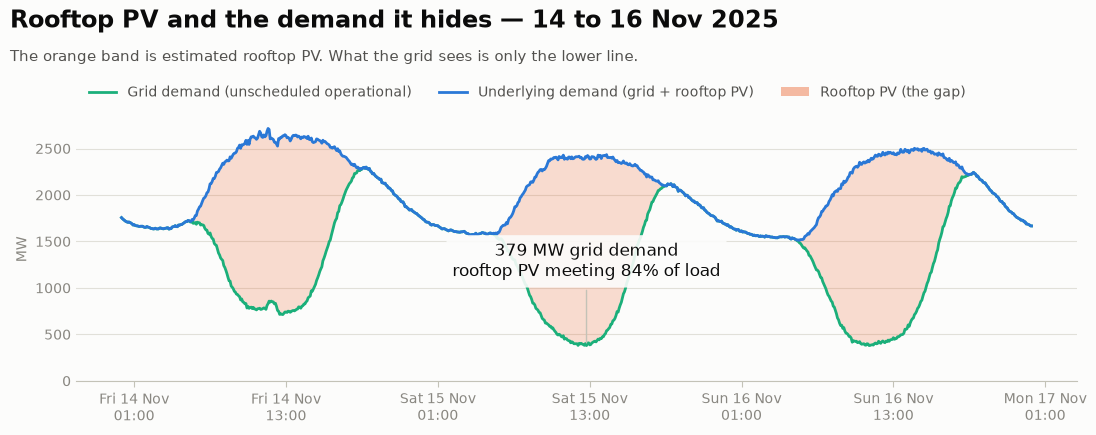

In [14]:
# ── Chart 4: rooftop PV against the demand it hides ──────────────
from wa_data import load_demand

dem = load_demand(raw='../data/raw')
both = add_time_parts(dem.merge(df, on="ts", how="inner"))
both["underlying_mw"] = both.unscheduled_demand_mw + both.dpv_mw   # STATED ASSUMPTION, see above
byr = both[both.year == YEAR]

# The minimum-grid-demand interval of the year, and the day it falls on.
lo = byr.loc[byr.unscheduled_demand_mw.idxmin()]
MIN_DAY = lo.date
print(f"minimum unscheduled demand {YEAR}: {lo.unscheduled_demand_mw:,.0f} MW at {lo.ts}")
print(f"  rooftop PV at that moment: {lo.dpv_mw:,.0f} MW")
print(f"  share of underlying demand met by rooftop PV: {lo.dpv_mw / lo.underlying_mw:.1%}")

win_start = MIN_DAY - pd.Timedelta(days=1)
dayw = byr[(byr.ts >= win_start) & (byr.ts < win_start + pd.Timedelta(days=3))]

fig, ax = plt.subplots(figsize=(11, 4.7))
# The fill between the two lines IS the rooftop PV series.
ax.fill_between(dayw.ts, dayw.unscheduled_demand_mw, dayw.underlying_mw,
                 color=ORANGE, alpha=0.22, linewidth=0)
ax.plot(dayw.ts, dayw.unscheduled_demand_mw, color=AQUA, linewidth=2,
        label="Grid demand (unscheduled operational)")
ax.plot(dayw.ts, dayw.underlying_mw, color=BLUE, linewidth=2,
        label="Underlying demand (grid + rooftop PV)")
# Legend proxy for the filled band, so the orange area is named rather than inferred.
gap_proxy = Patch(facecolor=ORANGE, alpha=0.45, label="Rooftop PV (the gap)")

# Label sits ABOVE the trough, inside the band: below it would land on the axis
# tick labels. The surface-coloured backing keeps it legible over the fill.
ax.annotate(
    f"{lo.unscheduled_demand_mw:,.0f} MW grid demand\n"
    f"rooftop PV meeting {lo.dpv_mw / lo.underlying_mw:.0%} of load",
    xy=(lo.ts, lo.unscheduled_demand_mw), xytext=(0, 46), textcoords="offset points",
    ha="center", va="bottom", color=INK, fontsize=12,
    arrowprops=dict(arrowstyle="-", color=AXIS, lw=1),
    bbox=dict(facecolor=SURFACE, alpha=0.9, edgecolor="none", boxstyle="round,pad=0.35"))

ax.set_ylim(bottom=0)
ax.set_ylabel("MW", color=MUTED)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b\n%H:%M"))

fig.subplots_adjust(top=0.72, bottom=0.16, left=0.07, right=0.98)
style(fig, ax, "Rooftop PV and the demand it hides — "
              f"{win_start:%d} to {win_start + pd.Timedelta(days=2):%d %b %Y}",
      "The orange band is estimated rooftop PV. What the grid sees is only the lower line.",
      title_y=0.95, subtitle_y=0.865)

handles, labels = ax.get_legend_handles_labels()
handles.append(gap_proxy); labels.append("Rooftop PV (the gap)")
ax.legend(handles, labels, loc="lower left", bbox_to_anchor=(0, 1.02), ncol=3,
          frameon=False, labelcolor=INK_2)
plt.show()

In [15]:
# ── Chart 4 in numbers: how much demand rooftop PV hides, and when ───────────
share_year = byr.dpv_mw.sum() / byr.underlying_mw.sum()
print(f"{YEAR} rooftop PV energy:        {byr.dpv_mw.sum() / 12 / 1000:>9,.0f} GWh")
print(f"{YEAR} underlying demand energy: {byr.underlying_mw.sum() / 12 / 1000:>9,.0f} GWh")
print(f"{YEAR} rooftop PV share of underlying demand: {share_year:.1%}")

midday = byr[(byr.tod_min >= 660) & (byr.tod_min <= 780)]        # 11:00-13:00
print("\nMidday (11:00–13:00) share of underlying demand met by rooftop PV, by season:")
print((midday.groupby("season")
       .apply(lambda g: g.dpv_mw.sum() / g.underlying_mw.sum(), include_groups=False)
       .reindex(seasons).map("{:.1%}".format)).to_string())

# How often rooftop PV out-supplies the grid
share = byr.dpv_mw / byr.underlying_mw
for t in (0.5, 0.7, 0.8):
    hit = byr[share > t]
    print(f"rooftop PV > {t:.0%} of underlying demand: {len(hit):6,} intervals "
          f"({len(hit) / len(byr):5.1%}) on {hit.date.nunique():3} days")
print("days with any interval above 50%, by season:",
      byr[share > 0.5].groupby("season").date.nunique().reindex(seasons).to_dict())

# Underlying vs grid demand on the average day (30-min)
u30 = add_time_parts(to_trading_intervals(byr, ["unscheduled_demand_mw", "dpv_mw"]))
u30["underlying_mw"] = u30.unscheduled_demand_mw + u30.dpv_mw
up = u30.groupby(["season", "tod_min"])[["underlying_mw", "unscheduled_demand_mw"]].mean()
rows = []
for s in seasons:
    p = up.loc[s]
    rows.append({"season": s,
                 "grid min 10–13": p.loc[600:780, "unscheduled_demand_mw"].min(),
                 "underlying min 10–13": p.loc[600:780, "underlying_mw"].min(),
                 "underlying overnight min": p.loc[0:330, "underlying_mw"].min(),
                 "underlying daily max": p.underlying_mw.max(),
                 "at": hhmm(p.underlying_mw.idxmax())})
print(f"\nAverage day, underlying vs grid demand, {YEAR} (MW):")
print(pd.DataFrame(rows).set_index("season").round(0).to_string())

gp = u30.loc[u30.unscheduled_demand_mw.idxmax()]
upk = u30.loc[u30.underlying_mw.idxmax()]
print(f"\nAnnual peak, grid demand:       {gp.unscheduled_demand_mw:,.0f} MW at {gp.ts}  (rooftop PV {gp.dpv_mw:,.0f} MW)")
print(f"Annual peak, underlying demand: {upk.underlying_mw:,.0f} MW at {upk.ts}  (rooftop PV {upk.dpv_mw:,.0f} MW)")

# The minimum-demand record at two resolutions
print("\nDaily minimum grid demand, 14–16 Nov, at both resolutions:")
for label, f in (("5-min", byr), ("30-min", u30)):
    w = f[(f.ts >= win_start) & (f.ts < win_start + pd.Timedelta(days=3))]
    for d, g in w.groupby("date"):
        r = g.loc[g.unscheduled_demand_mw.idxmin()]
        print(f"  {label:6s} {d:%a %d %b}: {r.unscheduled_demand_mw:6.1f} MW at {r.ts:%H:%M}")
    print(f"  {label:6s} annual minimum falls on {f.loc[f.unscheduled_demand_mw.idxmin(), 'ts']:%a %d %b}")

2025 rooftop PV energy:            4,291 GWh
2025 underlying demand energy:    21,955 GWh
2025 rooftop PV share of underlying demand: 19.5%

Midday (11:00–13:00) share of underlying demand met by rooftop PV, by season:
season
Summer    53.6%
Autumn    52.8%
Winter    41.9%
Spring    63.1%
rooftop PV > 50% of underlying demand: 14,412 intervals (13.7%) on 261 days
rooftop PV > 70% of underlying demand:  2,104 intervals ( 2.0%) on  61 days
rooftop PV > 80% of underlying demand:    227 intervals ( 0.2%) on   8 days
days with any interval above 50%, by season: {'Summer': 67, 'Autumn': 70, 'Winter': 39, 'Spring': 85}

Average day, underlying vs grid demand, 2025 (MW):
        grid min 10–13  underlying min 10–13  underlying overnight min  underlying daily max     at
season                                                                                             
Summer          1507.0                3136.0                    1965.0                3643.0  14:30
Autumn          1343.0      

### Findings

Numbers are from the two cells above (2025; 5-minute unless stated).

- At the year's lowest grid demand (Sat 15 Nov, 12:45) the grid supplied 379 MW while estimated rooftop PV supplied 2,026 MW, **84% of underlying demand**. Across the whole year rooftop PV met 19.5% of underlying demand, and between 42% (Winter) and 63% (Spring) of it at 11:00–13:00.
- Rooftop PV out-supplied the grid (more than 50% of underlying demand) in 13.7% of all intervals, on 261 days. That happened on 85 days in Spring but only 39 in Winter. The minimum-demand weekend is extreme even so: PV exceeded 80% in only 227 intervals, on 8 days.
- **The midday trough in grid demand is a rooftop PV effect, not lower consumption.** On the average day, underlying demand between 10:00 and 13:00 never falls below 2,668–3,136 MW, well above its overnight minimum (1,748–1,965 MW) in every season. Grid demand over the same hours drops to 978–1,615 MW. In Spring, underlying demand is essentially flat through the middle of the day and peaks at 11:30; in Summer it peaks at 14:30.
- **Rooftop PV moves and lowers the system peak.** Underlying demand peaked at 5,197 MW at 13:30 on 20 January, when rooftop PV was supplying 1,363 MW. Grid demand peaked the same day at 18:30, at 4,454 MW, with rooftop PV down to 82 MW. The peak the grid has to meet is about 740 MW lower and arrives five hours later, in the early evening when PV is nearly gone.
- The minimum-demand record depends on resolution. At 5 minutes, Saturday 15 Nov (378.9 MW at 12:45) edges out Sunday 16 Nov (379.1 MW at 11:05) by 0.2 MW. At 30 minutes, Sunday wins (385.9 vs 394.4 MW) because Saturday's dip is deeper but narrower and the half-hour mean clips it harder. This is why the demand notebook reports 386 MW on 16 November. Neither is wrong, but a minimum-demand record should always be quoted with its resolution.

> **Caveat — underlying demand inherits every weakness of the PV estimate.** AEMO does not publish a method for this series. It also publishes an older 30-minute estimate (`distributed-pv/distributed-pv-YYYY.csv`) that, checked outside this notebook, has 7.9% more energy than this series in 2025, correlates at only 0.93 at 30 minutes, and differs by up to 1,900 MW in a single half-hour. The artefacts found in Chart 2 (frozen readings, one-interval spikes) pass straight into underlying demand. Read the shares and profiles above as indicative, to within several percent, not as measured values.

### Implication
- [placeholder]